# House Prediction ML project

---
## Objective:

*The main core purpose of this project is to predict house prices giving the set of features from the dataset downloaded from kaggle*

## Problem Type:

- Supervised Learning
- Regression
- Batch Learning

## Target varible:

- SalesPrice

**We have already a seperated dataset for testing, so we can use the whole training dataset for exploration**

#### Making Imports:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder,
    FunctionTransformer,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

---
## Exploratory Data Analysis(EDA)

In [2]:
# Load the dataset
data= pd.read_csv('../data/train.csv')
# Create a copy of the dataset for EDA
data_train= data.copy()    
# Seperating the label (i.e The target variable) from the features
data_copy= data_train.drop('SalePrice', axis=1)
target_var= data['SalePrice']

**Taking a quick look at the data structure:**

In [3]:
# Numerical & categorical columns
num_cols = data_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = data_train.select_dtypes(include=["object"]).columns.tolist()

# 1. Basic info
print(f"Shape: {data_train.shape[0]} rows, {data_train.shape[1]} columns\n")
print(f"Data types:\n{data_train.dtypes}\n")
print(f"Numerical columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

Shape: 1460 rows, 81 columns

Data types:
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
Alley                str
LotShape             str
LandContour          str
Utilities            str
LotConfig            str
LandSlope            str
Neighborhood         str
Condition1           str
Condition2           str
BldgType             str
HouseStyle           str
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle            str
RoofMatl             str
Exterior1st          str
Exterior2nd          str
MasVnrType           str
MasVnrArea       float64
ExterQual            str
ExterCond            str
Foundation           str
BsmtQual             str
BsmtCond             str
BsmtExposure         str
BsmtFinType1         str
BsmtFinSF1         int64
BsmtFinType2         str
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsm

C:\Users\asad\AppData\Local\Temp\ipykernel_19844\3588566667.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data_train.select_dtypes(include=["object"]).columns.tolist()


After going through the dataset and exploring the feature audit, also what would I look for while buying an ideal house for me, I extracted some relevent features simplifying early-stage analysis and preprocessing.  
These are enough for a strong baseline model, We can add more features afterwards depending on the model performance.

---

### Selected Features

These are total 18 features in which 13 are numerical and 5 categorical(i.e You can find the meaning of every variable in the attatched features descryption):

- LotConfig
- Neighborhood
- KitchenQual
- OverallQual
- 2ndFlrSF
- 1stFlrSF
- TotalBsmtSF
- YearBuilt
- YearRemodAdd
- ExterQual
- BsmtQual
- FullBath
- BsmtFullBath
- HalfBath
- BsmtHalfBath
- GrLivArea
- TotRmsAbvGrd
- GarageCars

Target Variable:
- SalePrice

---

### Features Removed Initially

Some features were excluded because they:
- had near-zero variance
- contained excessive missing values
- were highly sparse
- had low expected predictive value

Examples:
- Id
- Utilities
- Street
- Condition2
- RoofMatl

---

### Strategy

The goal at this stage is:
- understanding ML workflow
- building a clean preprocessing pipeline
- creating a reliable baseline model
- reducing project complexity

---
## Exploring Numerical features

               count         mean         std     min      25%     50%  \
OverallQual   1460.0     6.099315    1.382997     1.0     5.00     6.0   
2ndFlrSF      1460.0   346.992466  436.528436     0.0     0.00     0.0   
1stFlrSF      1460.0  1162.626712  386.587738   334.0   882.00  1087.0   
TotalBsmtSF   1460.0  1057.429452  438.705324     0.0   795.75   991.5   
YearBuilt     1460.0  1971.267808   30.202904  1872.0  1954.00  1973.0   
YearRemodAdd  1460.0  1984.865753   20.645407  1950.0  1967.00  1994.0   
FullBath      1460.0     1.565068    0.550916     0.0     1.00     2.0   
BsmtFullBath  1460.0     0.425342    0.518911     0.0     0.00     0.0   
HalfBath      1460.0     0.382877    0.502885     0.0     0.00     0.0   
BsmtHalfBath  1460.0     0.057534    0.238753     0.0     0.00     0.0   
GrLivArea     1460.0  1515.463699  525.480383   334.0  1129.50  1464.0   
TotRmsAbvGrd  1460.0     6.517808    1.625393     2.0     5.00     6.0   
GarageCars    1460.0     1.767123    0

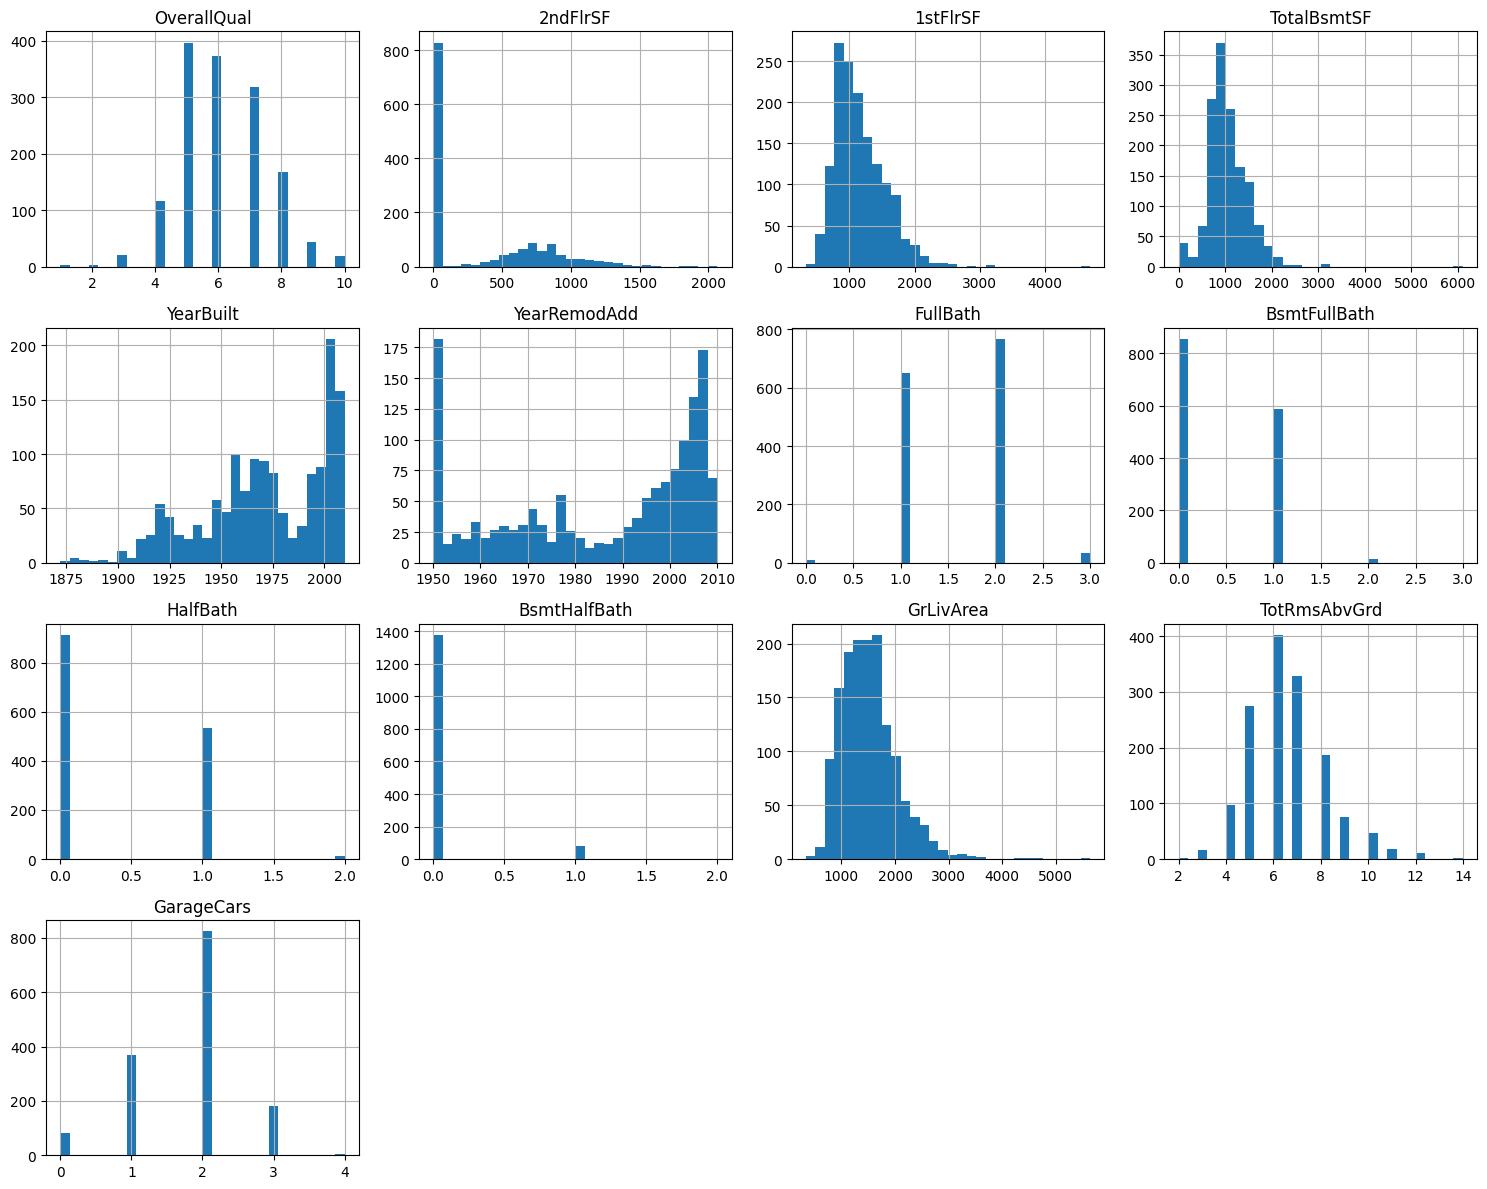

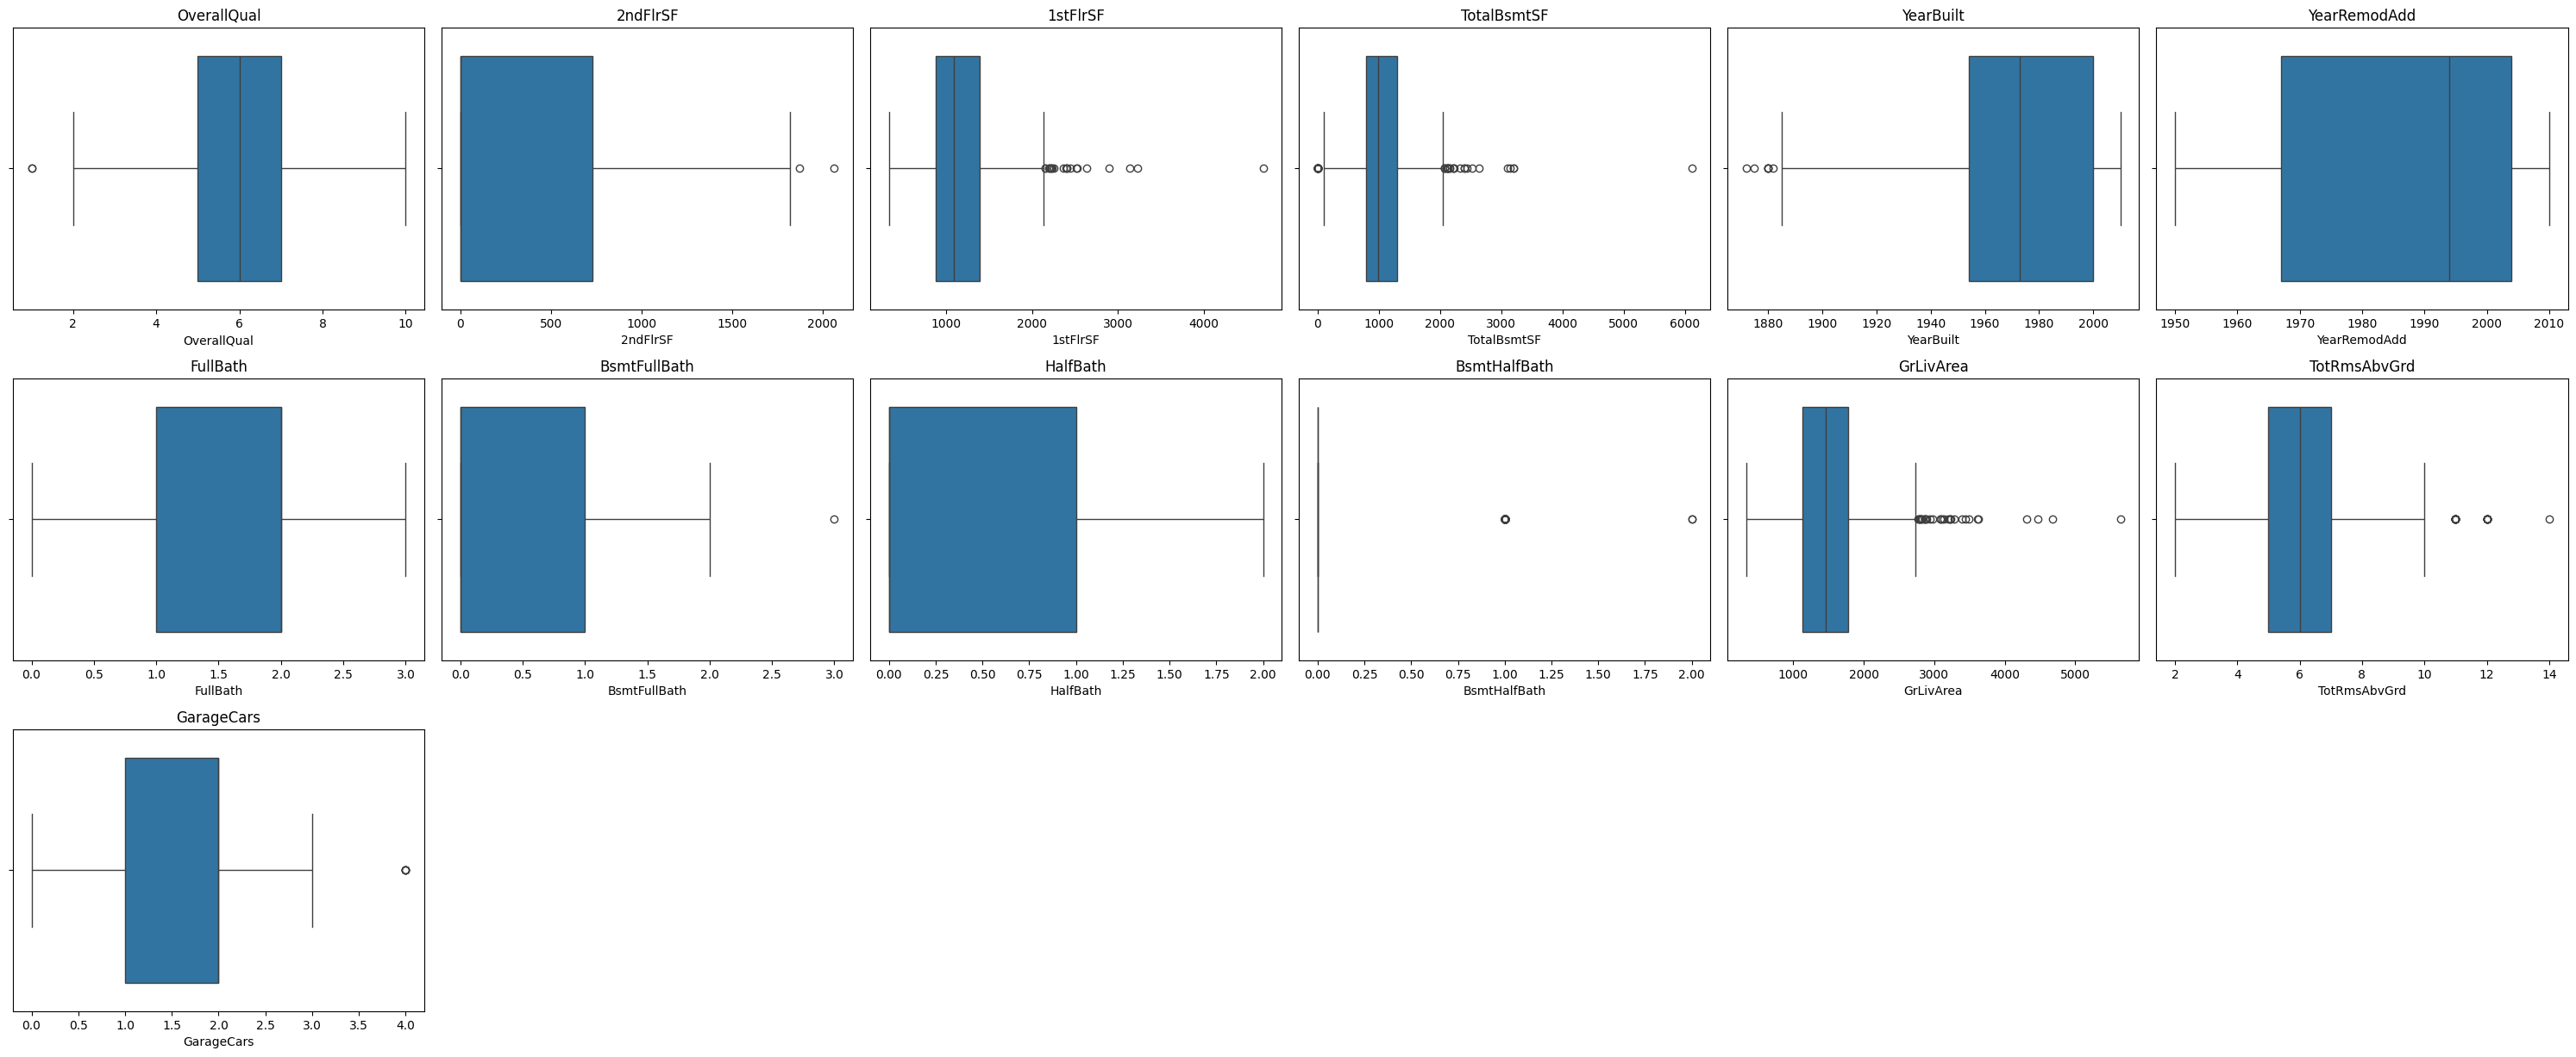

In [4]:
# Selected features
selected_features = [
    "LotConfig",
    "Neighborhood",
    "KitchenQual",
    "OverallQual",
    "2ndFlrSF",
    "1stFlrSF",
    "TotalBsmtSF",
    "YearBuilt",
    "YearRemodAdd",
    "ExterQual",
    "BsmtQual",
    "FullBath",
    "BsmtFullBath",
    "HalfBath",
    "BsmtHalfBath",
    "GrLivArea",
    "TotRmsAbvGrd",
    "GarageCars"
]

def select_features(df):
    return df[selected_features].copy()

# Create reduced dataframe
data_copy = select_features(data_train)

# Extract numerical columns
num_cols = data_copy.select_dtypes(include="number").columns.tolist()

# Basic statistics
print(data_copy[num_cols].describe().T)

# Missing values
print("\nMissing Values:\n")
print(data_copy[num_cols].isnull().sum())

# Skewness
print("\nSkewness:\n")
print(data_copy[num_cols].skew())

# Histograms
data_copy[num_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

# Create boxplots
plt.figure(figsize=(30, 16))

for i, col in enumerate(num_cols, 1):

    plt.subplot(4, 6, i)

    sns.boxplot(
        x=data_copy[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

### Outcomes:

- LotArea, TotalBsmtSF, and GrLivArea are heavily right skewed and need to be transformmed for our regreession model to generzalize well
- LotArea and GrLivArea contains some extreme high outliers we need to take care of it
- 2ndFlrSF contains mostly zero values as there are many houses with no second floor
- Luckily, we dont have any missing values in the columns

---
## Correlation between features


Correlation with SalePrice:

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
2ndFlrSF        0.319334
HalfBath        0.284108
BsmtFullBath    0.227122
BsmtHalfBath   -0.016844
dtype: float64


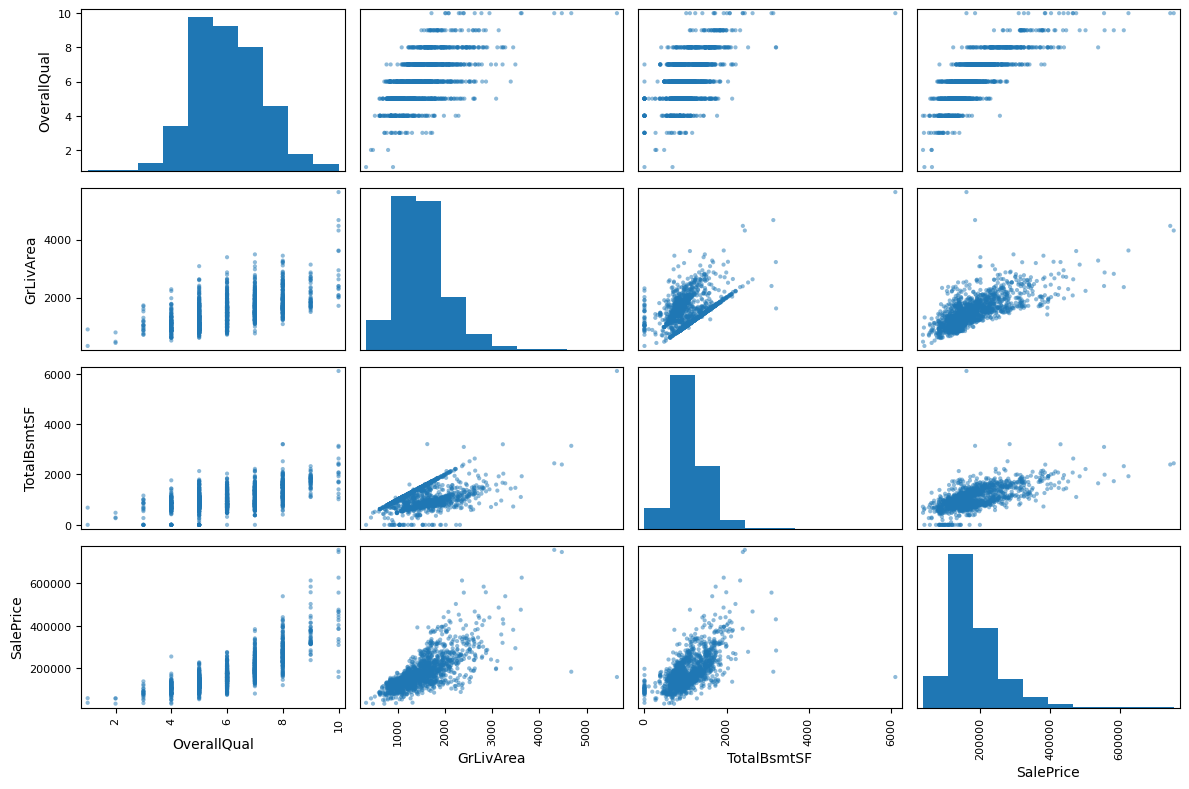

In [5]:
# Correlation with target
corr_matrix = data_copy[num_cols].corrwith(target_var)

print("\nCorrelation with SalePrice:\n")
print(
    corr_matrix
    .sort_values(ascending=False))

# Extracting important variables

imp_cols= ["OverallQual", "GrLivArea", "TotalBsmtSF"]

# Correlation of selected variables

scatter_matrix(data_copy[imp_cols].join(target_var), figsize=(12, 8))
plt.tight_layout()
plt.show()

### Outcomes

- OverallQual seems to be most linear with the SalePrice as it should be
- TotalBsmtSF and GrLivArea are strongly coorelated also we see a sharp edge line between as in most conditions they would be exactly equal
- TotalBsmtSF and GrLivArea are positively correlated but some of the few houses having the largest GrLivArea and corresponding TotalBsmtSF are tend to have lower SalePrice than usual which could be potential anomalies

---
## Exploring Categorical Features

 
  COLUMN : LotConfig
  Unique : 5    Missing : 0 (0.0%)
           count     %
LotConfig             
Inside      1052  72.1
Corner       263  18.0
CulDSac       94   6.4
FR2           47   3.2
FR3            4   0.3


C:\Users\asad\AppData\Local\Temp\ipykernel_19844\1847178741.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data_copy.select_dtypes(include="object").columns.tolist()


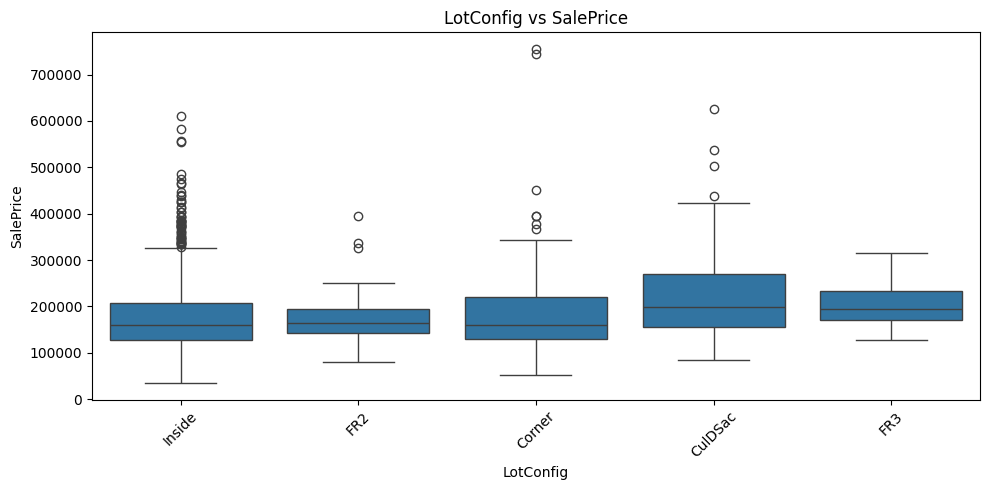

 
  COLUMN : Neighborhood
  Unique : 25    Missing : 0 (0.0%)
  (showing top 10 of 25 categories)

              count     %
Neighborhood             
NAmes           225  15.4
CollgCr         150  10.3
OldTown         113   7.7
Edwards         100   6.8
Somerst          86   5.9
Gilbert          79   5.4
NridgHt          77   5.3
Sawyer           74   5.1
NWAmes           73   5.0
SawyerW          59   4.0


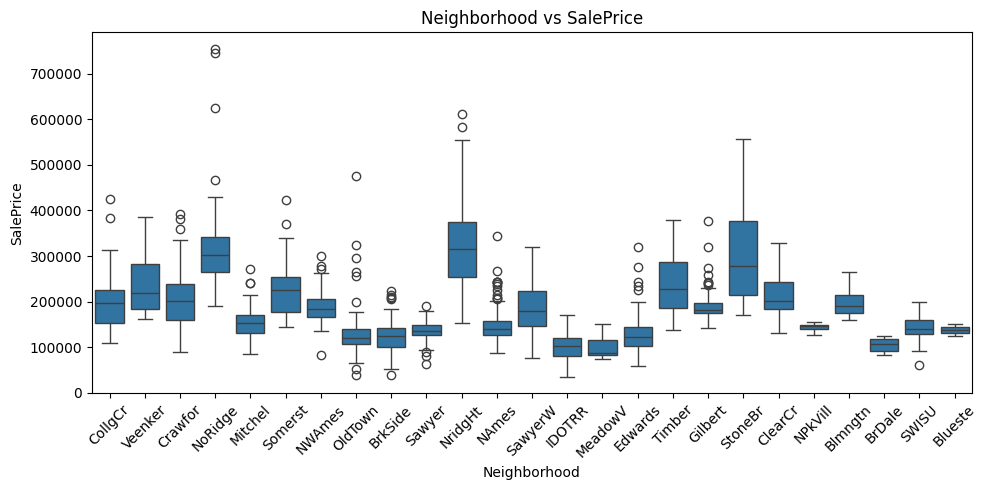

 
  COLUMN : KitchenQual
  Unique : 4    Missing : 0 (0.0%)
             count     %
KitchenQual             
TA             735  50.3
Gd             586  40.1
Ex             100   6.8
Fa              39   2.7


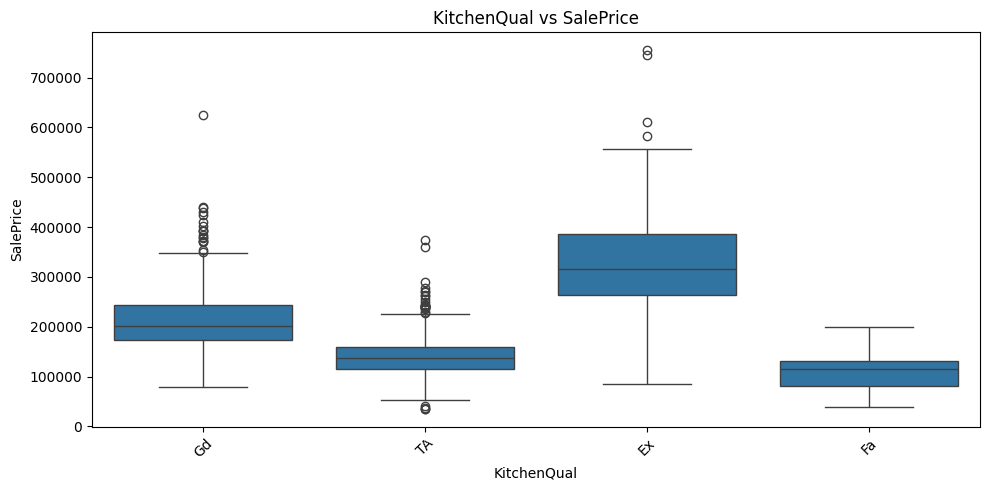

 
  COLUMN : ExterQual
  Unique : 4    Missing : 0 (0.0%)
           count     %
ExterQual             
TA           906  62.1
Gd           488  33.4
Ex            52   3.6
Fa            14   1.0


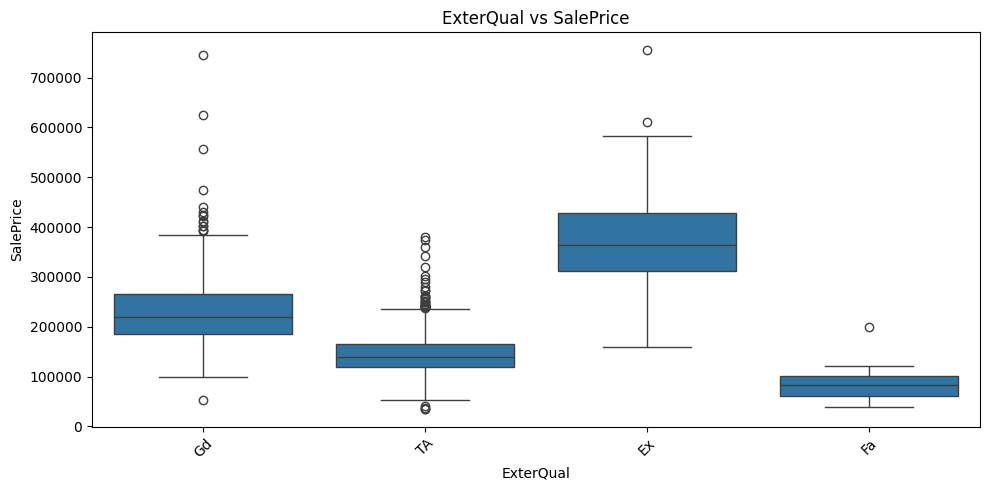

 
  COLUMN : BsmtQual
  Unique : 5    Missing : 37 (2.5%)
          count     %
BsmtQual             
TA          649  44.5
Gd          618  42.3
Ex          121   8.3
Fa           35   2.4


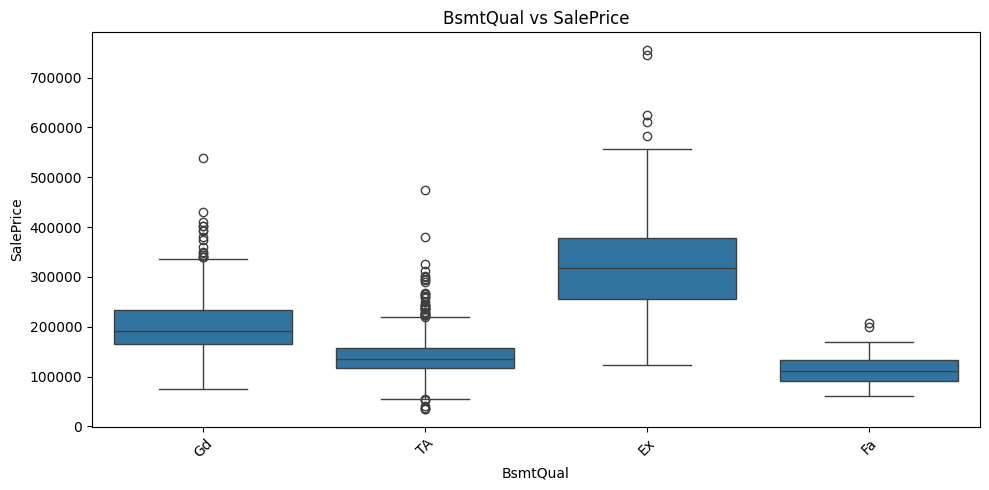

In [6]:
cat_cols = data_copy.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    
    # Unique and missing values

    n_unique = data_copy[col].nunique(dropna=False)
    n_missing = data_copy[col].isnull().sum()
    miss_pct = round(n_missing / len(data_copy) * 100, 1)
 
    print(" ")
    print(f"  COLUMN : {col}")
    print(f"  Unique : {n_unique}    Missing : {n_missing} ({miss_pct}%)")

    # value counts table

    vc = data_copy[col].value_counts()
    vc_pct = (vc / len(data_copy) * 100).round(1)
    summary = pd.DataFrame({"count": vc, "%": vc_pct})
 
    if len(summary) > 10:
        print(f"  (showing top 10 of {len(summary)} categories)\n")
        summary = summary.head(10)
        
    print(summary.to_string())

    # Box plots for categorical variables

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=data_copy[col],
        y=target_var
    )

    plt.title(f"{col} vs SalePrice")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

### Outcomes:

- BsmtQual have some missing values we have to fill or drop those values
- Corner-lot houses located in the NoRidge neighborhood, along with homes having excellent kitchen, exterior, and basement quality, tend to show significantly higher sale prices. This suggests that these features may act as strong predictors of house prices. The model may learn a pattern where the combination of premium location and high-quality construction characteristics contributes positively to the overall SalePrice.
- We dont see any visible outlier here
- As we need to convert these categories to numbers to give better understanding to our algortihm we will apply following type of encoding to each category:

Ordinal Encoding: KitchenQual, ExterQual, BsmtQual

OneHotEncoding: LotConfig, Neighborhood

---
## Dealing with Outliers:

#### First we need to have a look at values that seems to be potential outlier

In [7]:
filtered = data[
    data["GrLivArea"] > 4000
]

filtered2 = data[
    data["TotalBsmtSF"] > 4000
]

print(filtered[cat_cols + num_cols + ["SalePrice"]])

print(filtered2[cat_cols + num_cols + ["SalePrice"]])

     LotConfig Neighborhood KitchenQual ExterQual BsmtQual  OverallQual  \
523     Inside      Edwards          Ex        Ex       Ex           10   
691     Corner      NoRidge          Ex        Ex       Ex           10   
1182    Corner      NoRidge          Ex        Gd       Ex           10   
1298    Corner      Edwards          Ex        Ex       Ex           10   

      2ndFlrSF  1stFlrSF  TotalBsmtSF  YearBuilt  YearRemodAdd  FullBath  \
523       1538      3138         3138       2007          2008         3   
691       1872      2444         2444       1994          1995         3   
1182      2065      2411         2396       1996          1996         3   
1298       950      4692         6110       2008          2008         2   

      BsmtFullBath  HalfBath  BsmtHalfBath  GrLivArea  TotRmsAbvGrd  \
523              1         1             0       4676            11   
691              0         1             1       4316            10   
1182             1         1  

### Outcome:

- One clear outlier seen here is at index 1298 as this house have all the qualities that an ideal house have according to this data still it is having lower SalePrice that could be a data entry error or something so it's better to remove it to protect our model reading that anomaly.
- Another outlier i would consider is at index 523 as it has second highest GrLivArea and all the better qualities of an ideal house still causing low price than usual
- The other two outliers would be considerable as there features coorelates with the housing price 

### Removing outliers:

In [8]:
data_copy.drop([1298, 523], inplace=True)
target_var.drop([1298, 523], inplace=True)
data_train.drop([1298, 523], inplace=True)

### Handling Outliers in Production / Test Data

During EDA we **removed** rows 1298 and 523 from training because they were clear
anomalies

We cannot remove rows from test or production data. Instead the pipeline **caps**
(clips) extreme values at safe upper bounds derived from the cleaned training
distribution. This prevents the model from extrapolating wildly on values it has
never seen during training.

In [9]:
outlier_caps = {
    "OverallQual": (1, 10),
    "TotalBsmtSF": (0, 3500),
    "YearBuilt": (1870, 2010),
    "YearRemodAdd": (1950, 2010),
    "FullBath": (0, 5),
    "BsmtFullBath": (0, 5),
    "HalfBath": (0, 3),
    "BsmtHalfBath": (0, 3),
    "GrLivArea": (300, 4700),
    "TotRmsAbvGrd": (1, 15),
    "GarageCars": (0, 5)
}

def clip_outliers(df):
    df = df.copy()
    for col, (lower, upper) in outlier_caps.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=lower, upper=upper)
    return df

---
## Feature Engineering

Now let's improve the quality and predictive power of the dataset. This process involves both feature addition and feature removal based on correlation analysis and domain understanding of the housing dataset.

### Adding New Features

#### Creating new meaningfull features by combining existing variables that better correlate with the target variable to improve performance of our model.

In [10]:
def add_features(df):
    df = df.copy()

    # Size combinations
    df["TotalSF"]          = df["TotalBsmtSF"] + df["GrLivArea"]
    df["TotalBaths"]       = (df["FullBath"] + df["BsmtFullBath"]
                              + 0.5 * df["HalfBath"] + 0.5 * df["BsmtHalfBath"])
    df["LivAreaPerRoom"]   = df["GrLivArea"] / df["TotRmsAbvGrd"].replace(0, 1)
 
    return df

data_copy = add_features(data_copy)

### Removing bad features

#### Let's remove highly correlated duplicate-style features to reduce unnecessary complexity and multicollinearity in the model. Removing less useful features will help simplify the dataset and improve model interpretability.

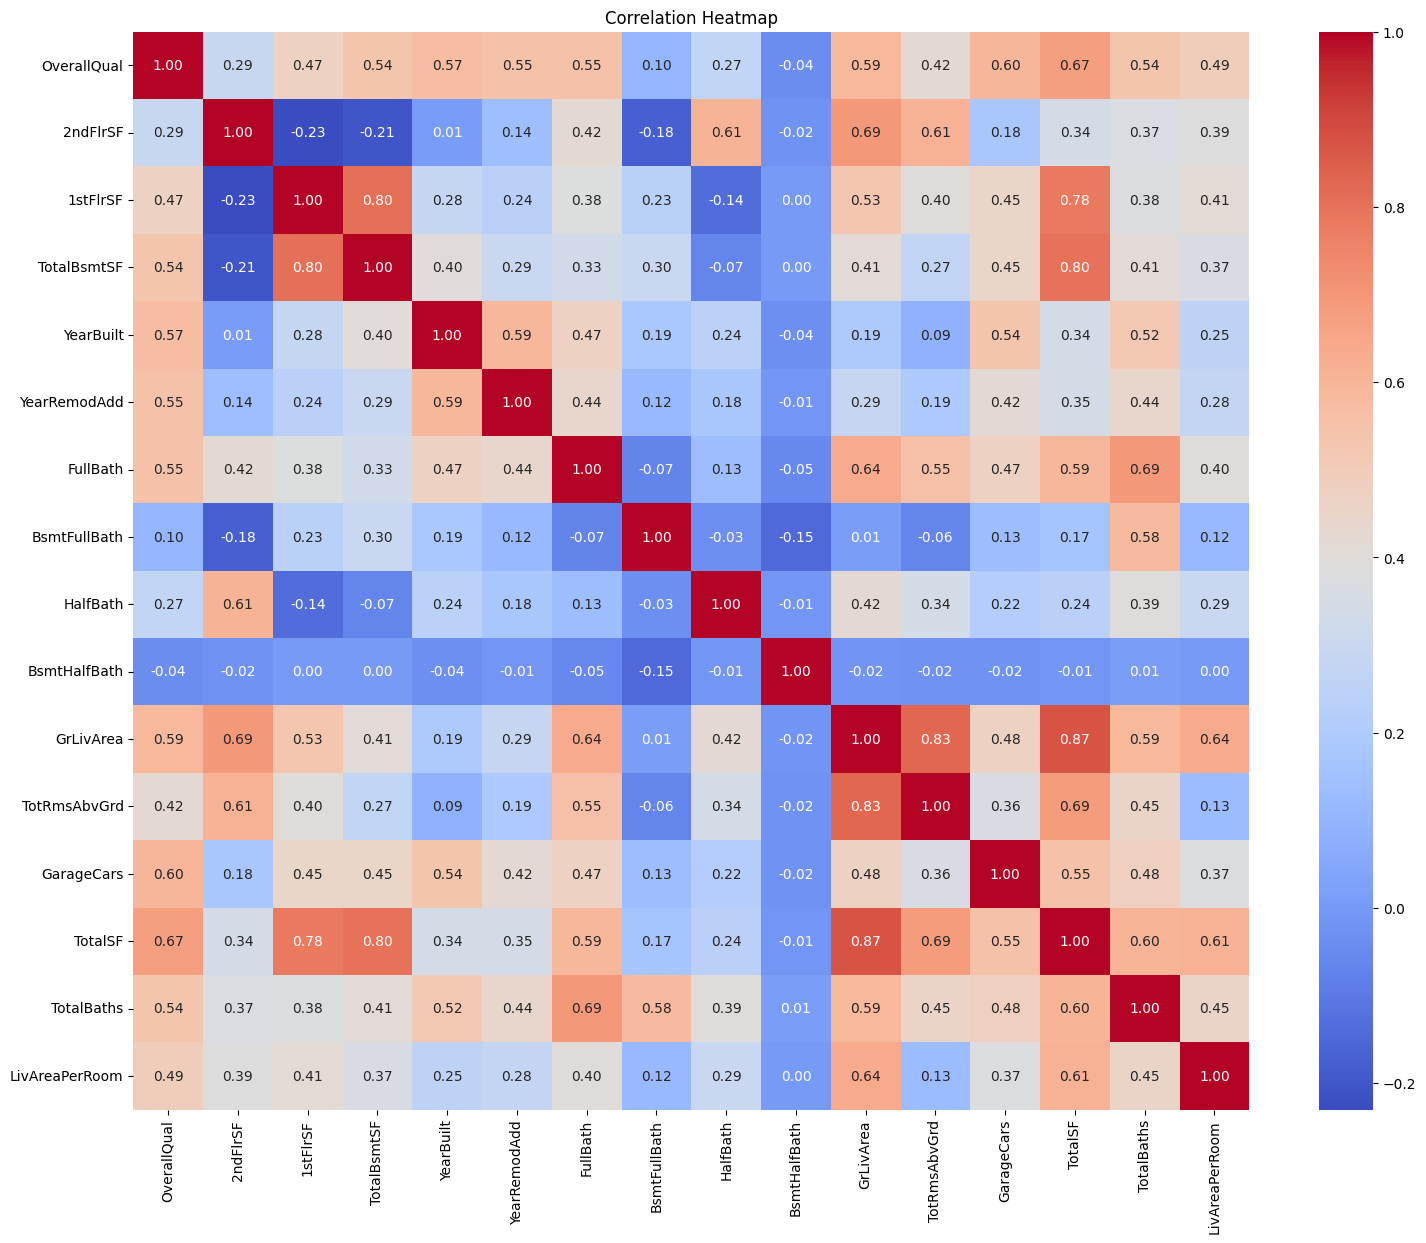

In [11]:
# Correlation matrix
num_cols = data_copy.select_dtypes(include="number").columns.tolist()
corr_matrix = data_copy[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [12]:
cols_to_drop = [
    "2ndFlrSF",       # LOW       — r~0.00  with SalePrice
    "TotalBsmtSF",    # HIGH      — r=0.80  with TotalSF (component of it)
    "1stFlrSF",       # HIGH      — r=0.78  with TotalSF (component of it)
    "TotRmsAbvGrd",   # HIGH      — r=0.83  with GrLivArea
    "BsmtFullBath",   # MEDIUM    — r=0.58  with TotalBaths
    "HalfBath",       # MEDIUM    — r=0.39  with TotalBaths
    "BsmtHalfBath",   # LOW       — r~0.00  with everything
]
final_data = data_copy.drop(cols_to_drop, axis=1)
num_cols = final_data.select_dtypes(include="number").columns.tolist()
print(f"After  : {final_data.shape[1]} features")
print(f"Columns  : {final_data.columns.tolist()} ")

# Correlation with target
corr_matrix = final_data[num_cols].corrwith(target_var)

print("\nCorrelation with SalePrice:\n")
print(
    corr_matrix
    .sort_values(ascending=False))

def drop_cols(df):
    return df.drop(cols_to_drop, axis=1)

After  : 14 features
Columns  : ['LotConfig', 'Neighborhood', 'KitchenQual', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'ExterQual', 'BsmtQual', 'FullBath', 'GrLivArea', 'GarageCars', 'TotalSF', 'TotalBaths', 'LivAreaPerRoom'] 

Correlation with SalePrice:

TotalSF           0.829042
OverallQual       0.795774
GrLivArea         0.734968
GarageCars        0.641047
TotalBaths        0.635896
FullBath          0.562165
LivAreaPerRoom    0.550517
YearBuilt         0.523608
YearRemodAdd      0.507717
dtype: float64


### Outcome

#### After performing feature engineering, the correlation of several features with the target variable improved noticeably. The newly engineered features captured more meaningful relationships within the data, which will help strengthen the predictive capability of the model.

---
## Transforming target variable

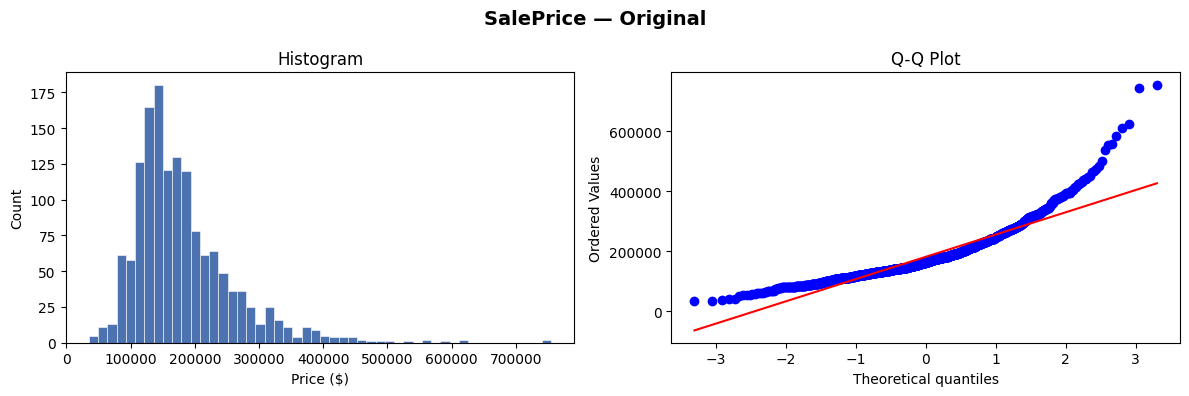

In [13]:
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
fig1.suptitle("SalePrice — Original", fontsize=14, fontweight="bold")
 
axes1[0].hist(target_var, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.4)
axes1[0].set_title("Histogram")
axes1[0].set_xlabel("Price ($)")
axes1[0].set_ylabel("Count")
 
stats.probplot(target_var, dist="norm", plot=axes1[1])
axes1[1].set_title("Q-Q Plot")
 
plt.tight_layout()
plt.show()

The target variable `SalePrice` is heavily right-skewed, meaning that most houses are concentrated in lower and medium price ranges while a small number of houses have extremely high prices. This skewness can negatively affect regression models because large values dominate the learning process and increase variance in predictions.

To reduce this skewness and stabilize the variance, a logarithmic transformation is applied

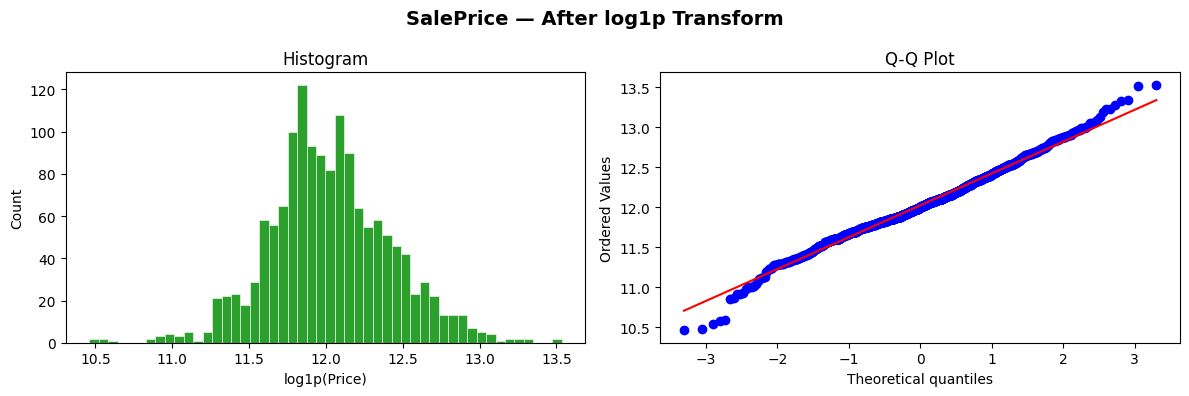

In [14]:
log_price = np.log1p(target_var)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle("SalePrice — After log1p Transform", fontsize=14, fontweight="bold")
 
axes2[0].hist(log_price, bins=50, color="#2ca02c", edgecolor="white", linewidth=0.4)
axes2[0].set_title("Histogram")
axes2[0].set_xlabel("log1p(Price)")
axes2[0].set_ylabel("Count")
 
stats.probplot(log_price, dist="norm", plot=axes2[1])
axes2[1].set_title("Q-Q Plot")
 
plt.tight_layout()
plt.show()
print()

---
## Data Transformation Pipeline

### After the analyzing part now we need to fix the data errors that we detected so we will transform our data for the better understanding of our model

#### Building Pipelines:

1. GrLivArea, TotalSF these two columns are heavily right-skewed a small number of very large houses pull the distribution far to the right. Regression models are good in generalizing normal distribution data so for this purpose, Taking the log compresses the long tail making the distribution more symmetric, log1p(x) is used instead of plain log(x) because it handles zeros safely

In [15]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log",   FunctionTransformer(np.log1p, feature_names_out="one-to-one"))
])


2. All the numerical values needed to be in standard form so the model doesn't learn from the magnitude of the values, StandardScaler() is applied to all that makes mean= 0 and std= 1

In [16]:
scale_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

3. BsmtQual have some missing values that needs to be filled, after analyzing we realized that those having Null value in BsmtQual don't have a basement. So we replaced the null values to NB(No Basement). In another step categorical values are converted to numbers as the algorithm works on numeric values so we use OrdinalEncoder for this purpose because they have a natural order (Poor < Fair < Average < Good < Excellent)

In [17]:
impute_encode = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encoder", OrdinalEncoder(
        categories=[
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"]         
],
        handle_unknown="use_encoded_value",
        unknown_value=-1,      
    ))
])

4. Remaining columns are nominal — their categories have no natural order. NoRidge is not "greater than" Edwards; they are just different places. Ordinal encoding would impose a false ordering, so OneHotEncoder is used instead.

In [18]:
onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore",
    ))
])

#### Putting It All Together:

- ColumnTransformer applies each pipeline to its designated columns in parallel and concatenates the results into a single matrix:

In [19]:
column_transformer = ColumnTransformer(
    transformers=[
        ("scale",      scale_pipeline,          num_cols),
        ("log_scale",  log_pipeline,           ["TotalSF", "GrLivArea"]),
        ("ordinal",    impute_encode,          ["KitchenQual", "ExterQual", "BsmtQual"]),
        ("onehot",     onehot_pipeline,        ["LotConfig", "Neighborhood"]),
    ])

preprocessing = Pipeline([
    ("select",    FunctionTransformer(select_features, validate=False)),
    ("clip",      FunctionTransformer(clip_outliers, validate=False)),
    ("engineer",  FunctionTransformer(add_features, validate=False)),
    ("drop_cols", FunctionTransformer(drop_cols, validate=False)),
    ("transform", column_transformer),
])

----
## Select and Train a model

### Let's quickly apply some baseline models to get a view of how our model is performing on this data

1. **Linear Regression:**

In [20]:
linear_reg_pipeline = Pipeline([
    ("preprocess", preprocessing),
    ("model",      LinearRegression()),
])

scores = cross_val_score(
    linear_reg_pipeline,
    data_train,
    log_price,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

linear_reg_pipeline.fit(data_train, log_price)
rmse_scores = -scores.round(2)

print("Cross-validation RMSE scores:")
print(rmse_scores)

print("Average RMSE:")
print(rmse_scores.mean().round(2))

print("Error Percentage %:")
print((rmse_scores.mean().round(2) / log_price.mean() * 100).round(2))

Cross-validation RMSE scores:
[0.13 0.14 0.14 0.13 0.13]
Average RMSE:
0.13
Error Percentage %:
1.08


2. ***Decision Tree Regressor:***

In [21]:
decision_tree_pipeline = Pipeline([
    ("preprocess", preprocessing),
    ("model", DecisionTreeRegressor(random_state=42)),
])

scores_dt = cross_val_score(
    decision_tree_pipeline,
    data_train,
    log_price,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores_dt = -scores_dt.round(2)     

print("\nDecision Tree Regressor RMSE scores:")
print(rmse_scores_dt)

print("Average RMSE:")
print(rmse_scores_dt.mean().round(2))

print("Error Percentage %:")
print((rmse_scores_dt.mean().round(2) / log_price.mean() * 100).round(2))


Decision Tree Regressor RMSE scores:
[0.21 0.21 0.2  0.19 0.19]
Average RMSE:
0.2
Error Percentage %:
1.66


3. ***Random Forest Regressor:***

In [22]:
random_forest_pipeline = Pipeline([
    ("preprocess", preprocessing),
    ("model", RandomForestRegressor(
        random_state=42
    )),
])

scores_rf = cross_val_score(
    random_forest_pipeline,
    data_train,
    log_price,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores_rf = -scores_rf.round(2)

print("\nRandom Forest Regressor RMSE scores:")
print(rmse_scores_rf)

print("Average RMSE:")
print(rmse_scores_rf.mean().round(2))

print("Error Percentage %:")
print((rmse_scores_rf.mean().round(2) / log_price.mean() * 100).round(2))


Random Forest Regressor RMSE scores:
[0.15 0.15 0.15 0.14 0.15]
Average RMSE:
0.15
Error Percentage %:
1.25


4. ***Support Vector Machine Regressor:***

In [23]:
svr_pipeline = Pipeline([
    ("preprocess", preprocessing),

    ("model", SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    )),
])
scores_svr = cross_val_score(
    svr_pipeline,
    data_train,
    log_price,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores_svr = -scores_svr.round(2)

print("SVR RMSE scores:")
print(rmse_scores_svr)

print("Average RMSE:")
print(rmse_scores_svr.mean().round(2))

print("Error Percentage %:")
print((rmse_scores_svr.mean().round(2) / log_price.mean() * 100).round(2))

SVR RMSE scores:
[0.14 0.15 0.15 0.13 0.15]
Average RMSE:
0.14
Error Percentage %:
1.16


### Final Outcomes and Model Comparison

Based on the cross-validation RMSE scores and estimated prediction error percentages, the following ranking of model performance was observed:

1. Linear Regression  
2. Support Vector Regressor (SVR)  
3. Random Forest Regressor  
4. Decision Tree Regressor  

- The Linear Regression model achieved the lowest average RMSE, indicating the best overall generalization performance on the dataset. This suggests that the selected and engineered features maintain a strong linear relationship with the target variable (`SalePrice`).

- The Support Vector Regressor also performed well and was able to capture some nonlinear relationships within the dataset. However, its performance was slightly below Linear Regression, likely due to the dataset characteristics and current hyperparameter configuration.

- The Random Forest Regressor produced stable and reliable predictions by combining multiple decision trees through ensemble learning. Although it handled nonlinear relationships effectively and reduced overfitting compared to a single Decision Tree.

- The Decision Tree Regressor achieved the weakest performance among the tested models. This is likely due to overfitting, as a single decision tree can easily memorize patterns from training folds while struggling to generalize well on unseen validation data.

Overall, the results indicate that the preprocessing pipeline, feature selection, feature engineering, handling of missing values, and logarithmic transformation of the target variable significantly improved the predictive capability of the models. The project also demonstrates how different machine learning algorithms respond differently to the same dataset and preprocessing workflow.

---
## Fine tuning the Model

#### Now as we explored some promising models, we need to fine tune their hyperparameters and find the best combination to make the performance of our model relatively well

In [24]:
svm_param_grid = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"]
}
grid_search_svm = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svm_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error"
)
grid_search_svm.fit(data_train, log_price)
print("Best hyperparameters for SVR:")
print(grid_search_svm.best_params_)
print(f"Best CV RMSE: {-grid_search_svm.best_score_.round(2)}")

Best hyperparameters for SVR:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV RMSE: 0.14


In [25]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__max_features": randint(1, 20),
    "model__min_samples_leaf": randint(1, 10)
    }

grid_cv_rf= RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42
)

grid_cv_rf.fit(data_train, log_price)
print("Best hyperparameters for Random Forest:")
print(grid_cv_rf.best_params_)
print(f"Best CV RMSE: {-grid_cv_rf.best_score_.round(2)}")

Best hyperparameters for Random Forest:
{'model__max_depth': 20, 'model__max_features': 14, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV RMSE: 0.14


## Hyperparameter Tuning Conclusion

Hyperparameter tuning slightly improved the performance of both models.  

The SVR model improved from an RMSE of `0.14` to `0.13`, making it the better-performing tuned model. The Random Forest Regressor also showed a small improvement, reducing its RMSE from `0.15` to `0.14`.

Overall, tuning helped optimize both models, although the improvements were moderate since the models were already performing well before tuning.

---
## Evaluating on the Test set:

In [26]:
# Load test data
test_data = pd.read_csv('../data/test.csv')

# Predict using each trained pipeline directly

log_pred_lr  = linear_reg_pipeline.predict(test_data)
log_pred_svr = grid_search_svm.predict(test_data)
log_pred_rf  = grid_cv_rf.predict(test_data)

# Reverse the log1p transformation applied to the target

pred_lr  = np.expm1(log_pred_lr)
pred_svr = np.expm1(log_pred_svr)
pred_rf  = np.expm1(log_pred_rf)

# Build submission DataFrames and save to CSV
submission_lr  = pd.DataFrame({"Id": test_data["Id"], "SalePrice": pred_lr})
submission_svr = pd.DataFrame({"Id": test_data["Id"], "SalePrice": pred_svr})
submission_rf  = pd.DataFrame({"Id": test_data["Id"], "SalePrice": pred_rf})

import os

# create folder if it doesn't exist
os.makedirs("../data/results", exist_ok=True)

submission_lr.to_csv('../data/results/submission_linear.csv',  index=False)
submission_svr.to_csv('../data/results/submission_svr.csv',    index=False)
submission_rf.to_csv('../data/results/submission_rf.csv',      index=False)

# Quick sanity check
print("Linear Regression — first 5 predictions:")
print(submission_lr.head())
print("\nSVR — first 5 predictions:")
print(submission_svr.head())
print("\nRandom Forest — first 5 predictions:")
print(submission_rf.head())


Linear Regression — first 5 predictions:
     Id      SalePrice
0  1461  110696.720593
1  1462  153421.985060
2  1463  162772.028510
3  1464  180983.794412
4  1465  211364.495051

SVR — first 5 predictions:
     Id      SalePrice
0  1461  116781.778410
1  1462  154892.362087
2  1463  171981.997656
3  1464  181991.183104
4  1465  190340.912149

Random Forest — first 5 predictions:
     Id      SalePrice
0  1461  111486.606333
1  1462  153362.891404
2  1463  172584.800581
3  1464  178343.045598
4  1465  190845.260771


---
## Saving the models

In [27]:
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(linear_reg_pipeline, '../models/linear_reg_pipeline.pkl')
joblib.dump(grid_search_svm.best_estimator_, '../models/svr_pipeline.pkl')
joblib.dump(grid_cv_rf.best_estimator_, '../models/rf_pipeline.pkl')

['../models/rf_pipeline.pkl']